## Lista de exercícios Tassio - Projeto EDA (Trabalho honesto onde me esforcei ao máximo para realiza-lo com muitas das habilidades que aprendi)

## LINK DO PROJETO NO MEU GITHUB https://github.com/tassio33/EDA_Projeto_ADA

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv('vendas_supermercado_com_cliente.csv')
df.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data         20075 non-null  object 
 1   Produto      20075 non-null  object 
 2   Categoria    20075 non-null  object 
 3   Preço        20075 non-null  float64
 4   Quantidade   20075 non-null  int64  
 5   Desconto     20075 non-null  float64
 6   Total_Venda  20075 non-null  float64
 7   Idade        20075 non-null  int64  
 8   Renda        20075 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 1.4+ MB


In [53]:
df.dtypes

Data            object
Produto         object
Categoria       object
Preço          float64
Quantidade       int64
Desconto       float64
Total_Venda    float64
Idade            int64
Renda          float64
dtype: object

In [54]:
df.shape

(20075, 9)

In [55]:
df.describe()

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000
mean,25.577109,10.007671,0.039760,245.901736,45.992827,2999.034265
std,14.115988,5.488450,0.085011,207.773694,16.482103,1159.717376
min,1.000000,1.000000,0.000000,0.910200,18.000000,1000.380000
25%,13.260000,5.000000,0.000000,75.604500,32.000000,1993.625000
50%,25.660000,10.000000,0.000000,186.320000,46.000000,2998.830000
75%,37.770000,15.000000,0.000000,370.040000,60.000000,4007.675000
max,49.990000,19.000000,0.500000,949.050000,74.000000,4999.760000


In [56]:
df.size

180675

In [57]:
df.columns

Index(['Data', 'Produto', 'Categoria', 'Preço', 'Quantidade', 'Desconto',
       'Total_Venda', 'Idade', 'Renda'],
      dtype='object')

In [58]:
df.loc[:, ['Total_Venda', 'Categoria']]

,Total_Venda,Categoria
0,164.6000,Alimentos Frescos
1,9.5600,Alimentos Frescos
2,41.9000,Alimentos Frescos
3,30.4500,Alimentos Frescos
4,519.9600,Alimentos Frescos
...,...,...
20070,315.4470,Pet Shop
20071,532.9500,Utilidades Domésticas
20072,235.1520,Utilidades Domésticas
20073,149.6625,Utilidades Domésticas


### 1. Quais foram as categorias de produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas?

In [59]:
df_valor_categoria =df.loc[:, ['Total_Venda', 'Categoria']].groupby('Categoria').sum().round(2).reset_index()
df_valor_categoria

,Categoria,Total_Venda
0,Alimentos Frescos,1365309.46
1,Bebidas,454394.16
2,Congelados,439720.13
3,Laticínios e Ovos,459960.47
4,Pet Shop,440331.56
5,Produtos de Higiene Pessoal,440039.48
6,Produtos de Limpeza,447545.86
7,Produtos de Mercearia,529653.65
8,Utilidades Domésticas,359522.58


In [60]:
df_valor_categoria.sort_values(by = 'Total_Venda', ascending = False, inplace = True)
df_valor_categoria


,Categoria,Total_Venda
0,Alimentos Frescos,1365309.46
7,Produtos de Mercearia,529653.65
3,Laticínios e Ovos,459960.47
1,Bebidas,454394.16
6,Produtos de Limpeza,447545.86
4,Pet Shop,440331.56
5,Produtos de Higiene Pessoal,440039.48
2,Congelados,439720.13
8,Utilidades Domésticas,359522.58


### Conforme extração acima, após sort values, o Grupo de produtos que teve mais vendas foi o grupo ALIMENTOS FRESCOS com um resultado de 1.365.309,46

### 2. Qual a média de vendas diárias por categoria de produto?

In [61]:
df.groupby('Categoria')['Total_Venda'].mean().round(2).sort_values(ascending = False)

Categoria
Laticínios e Ovos              252.03
Alimentos Frescos              249.37
Bebidas                        248.98
Utilidades Domésticas          246.25
Produtos de Limpeza            245.23
Produtos de Mercearia          241.85
Pet Shop                       241.28
Produtos de Higiene Pessoal    241.12
Congelados                     240.94
Name: Total_Venda, dtype: float64

### RESPOSTA: A média de vendas segue acima após groupby e sort values e mean. A Categoria com maior média de produtos foi a categoria de Laticínios e Ovos.

In [62]:
df['Data'] = pd.to_datetime(df['Data'])

In [63]:
print(df.dtypes)

Data           datetime64[ns]
Produto                object
Categoria              object
Preço                 float64
Quantidade              int64
Desconto              float64
Total_Venda           float64
Idade                   int64
Renda                 float64
dtype: object


In [64]:
df['mes'] = df['Data'].dt.month
df['ano'] = df['Data'].dt.year
df['Semana'] = df['Data'].dt.isocalendar().week
df['Dia'] = df['Data'].dt.day_name()

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data         20075 non-null  datetime64[ns]
 1   Produto      20075 non-null  object        
 2   Categoria    20075 non-null  object        
 3   Preço        20075 non-null  float64       
 4   Quantidade   20075 non-null  int64         
 5   Desconto     20075 non-null  float64       
 6   Total_Venda  20075 non-null  float64       
 7   Idade        20075 non-null  int64         
 8   Renda        20075 non-null  float64       
 9   mes          20075 non-null  int32         
 10  ano          20075 non-null  int32         
 11  Semana       20075 non-null  UInt32        
 12  Dia          20075 non-null  object        
dtypes: UInt32(1), datetime64[ns](1), float64(4), int32(2), int64(2), object(3)
memory usage: 1.8+ MB


In [66]:
df_valor_categoria2 = df.loc[:, ['Total_Venda', 'Categoria', 'mes']].groupby(['Categoria', 'mes']) ['Total_Venda'].sum().round(2).reset_index()

df_valor_categoria2

,Categoria,mes,Total_Venda
0,Alimentos Frescos,1,116281.50
1,Alimentos Frescos,2,109234.29
2,Alimentos Frescos,3,129103.45
3,Alimentos Frescos,4,98847.67
4,Alimentos Frescos,5,103923.98
...,...,...,...
103,Utilidades Domésticas,8,24887.67
104,Utilidades Domésticas,9,29466.35
105,Utilidades Domésticas,10,27710.77
106,Utilidades Domésticas,11,25441.03


In [67]:
vendas_mes = df_valor_categoria2.groupby(['Categoria', 'mes'])['Total_Venda'].sum().round(2).reset_index()
vendas_mes

,Categoria,mes,Total_Venda
0,Alimentos Frescos,1,116281.50
1,Alimentos Frescos,2,109234.29
2,Alimentos Frescos,3,129103.45
3,Alimentos Frescos,4,98847.67
4,Alimentos Frescos,5,103923.98
...,...,...,...
103,Utilidades Domésticas,8,24887.67
104,Utilidades Domésticas,9,29466.35
105,Utilidades Domésticas,10,27710.77
106,Utilidades Domésticas,11,25441.03


### Ainda da QUESTAO 1: Quais meses eles tiveram o maior pico de vendas?

In [68]:
resultado = vendas_mes.loc[vendas_mes.groupby('Categoria')['Total_Venda'].idxmax()].reset_index(drop = True)
resultado

,Categoria,mes,Total_Venda
0,Alimentos Frescos,3,129103.45
1,Bebidas,1,47415.71
2,Congelados,10,40418.34
3,Laticínios e Ovos,10,43440.80
4,Pet Shop,1,40577.29
5,Produtos de Higiene Pessoal,7,42213.35
6,Produtos de Limpeza,7,42358.75
7,Produtos de Mercearia,9,48192.29
8,Utilidades Domésticas,7,36674.81


### Acima segue resposta após uso do groupby , idxmax 

### 3. Quais produtos apresentam a maior sazonalidade nas vendas (ex: frutas e vegetais, sorvetes)?

In [69]:
sazonalidade_mensal = df.groupby(['Produto', 'mes'], as_index = False).agg({'Total_Venda': ['sum', 'mean','std'],'Quantidade': 'sum'}).round(2)
sazonalidade_mensal.columns = ['Produto', 'mes', 'Total_Venda_sum', 'Total_Venda_mean', 'Total_Venda_std', 'Quantidade_sum']


sazonalidade_mensal

,Produto,mes,Total_Venda_sum,Total_Venda_mean,Total_Venda_std,Quantidade_sum
0,Alface,1,9757.76,314.77,212.26,346
1,Alface,2,7983.28,285.12,208.08,286
2,Alface,3,9139.99,294.84,251.02,350
3,Alface,4,6960.46,232.02,209.11,299
4,Alface,5,5607.81,180.90,126.17,259
...,...,...,...,...,...,...
655,Óleo,8,6021.07,194.23,180.37,284
656,Óleo,9,7299.97,243.33,193.82,304
657,Óleo,10,6849.19,220.94,237.27,274
658,Óleo,11,7139.04,237.97,171.93,309


#### Cálculo da sazonalidade

In [70]:
sazonalidade_mensal['Sazonalidade'] = sazonalidade_mensal['Total_Venda_std'] / sazonalidade_mensal['Total_Venda_mean']

sazonalidade_mensal

,Produto,mes,Total_Venda_sum,Total_Venda_mean,Total_Venda_std,Quantidade_sum,Sazonalidade
0,Alface,1,9757.76,314.77,212.26,346,0.674334
1,Alface,2,7983.28,285.12,208.08,286,0.729798
2,Alface,3,9139.99,294.84,251.02,350,0.851377
3,Alface,4,6960.46,232.02,209.11,299,0.901259
4,Alface,5,5607.81,180.90,126.17,259,0.697457
...,...,...,...,...,...,...,...
655,Óleo,8,6021.07,194.23,180.37,284,0.928641
656,Óleo,9,7299.97,243.33,193.82,304,0.796531
657,Óleo,10,6849.19,220.94,237.27,274,1.073911
658,Óleo,11,7139.04,237.97,171.93,309,0.722486


In [71]:
sazonalidade_mensal.sort_values(by='Sazonalidade', ascending=False).head(3)

,Produto,mes,Total_Venda_sum,Total_Venda_mean,Total_Venda_std,Quantidade_sum,Sazonalidade
166,Croissants,11,6033.22,201.11,232.61,273,1.156631
200,Esponjas,9,6582.07,219.40,252.26,260,1.149772
501,Refrigerantes,10,6163.48,198.82,225.01,260,1.131727


### Os 3 produtos mais sazonais são: 
### Croissants no mês 11
### Esponjas no mês 9
### Refri no mês 10.


### 4. Quais as faixas etárias contribuíram mais para as vendas totais? Para responder essa pergunta, crie uma coluna com a faixa etária, considerando: 18 a 35 (Jovem), 36 e 59 (adulto) e acima de 60 anos (idoso)

In [72]:
def classificar_faixa_etaria(Idade):
    if Idade <= 35:
        return 'Jovem'
    elif Idade <= 59:    
        return 'Adulto'
    else:
        return 'Idoso'

In [73]:
df['faixa_etaria'] = df['Idade'].apply(classificar_faixa_etaria)
df.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,mes,ano,Semana,Dia,faixa_etaria
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61,1,2023,52,Sunday,Adulto
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15,1,2023,52,Sunday,Jovem
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56,1,2023,52,Sunday,Idoso
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17,1,2023,52,Sunday,Jovem
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42,1,2023,52,Sunday,Jovem


In [74]:
df_faixa_etaria = df.groupby(['faixa_etaria'])['Total_Venda'].sum().round(2).sort_values(ascending = False).reset_index()
df_faixa_etaria

,faixa_etaria,Total_Venda
0,Adulto,2102041.77
1,Jovem,1537183.38
2,Idoso,1297252.20


### A faixa etária que mais contribuiu para as vendas foi a faixa etária adulto 

### 5. Qual é a relação entre a idade dos clientes e a categoria de produto mais vendida para cada?

In [75]:
# Produto mais vendido por faixa etária

cat_faixa_etaria = df.groupby(['faixa_etaria', 'Categoria']) ['Quantidade'].sum().reset_index() 
cat_faixa_etaria

,faixa_etaria,Categoria,Quantidade
0,Adulto,Alimentos Frescos,23212
1,Adulto,Bebidas,7491
2,Adulto,Congelados,7499
3,Adulto,Laticínios e Ovos,7875
4,Adulto,Pet Shop,7989
5,Adulto,Produtos de Higiene Pessoal,7812
6,Adulto,Produtos de Limpeza,7497
7,Adulto,Produtos de Mercearia,9622
8,Adulto,Utilidades Domésticas,6012
9,Idoso,Alimentos Frescos,14365


In [76]:
maximo_fx_categoria = cat_faixa_etaria.loc[cat_faixa_etaria.groupby('faixa_etaria')['Quantidade'].idxmax()]
maximo_fx_categoria

,faixa_etaria,Categoria,Quantidade
0,Adulto,Alimentos Frescos,23212
9,Idoso,Alimentos Frescos,14365
18,Jovem,Alimentos Frescos,17178


### Todas as faixas etárias consomem em maior quantidade a Categoria Alimentos frescos

### 6. Qual a distribuição das vendas ao longo dos dias da semana?

In [77]:
vendas_por_dia = vendas_por_dia = df.groupby('Dia')['Total_Venda'].agg(['sum', 'mean', 'count']).round(2)
vendas_por_dia

,sum,mean,count
Dia,,,
Friday,707290.91,247.30,2860
Monday,695777.31,243.28,2860
Saturday,707984.37,247.55,2860
Sunday,722783.68,247.95,2915
Thursday,706311.13,246.96,2860
Tuesday,686277.94,239.96,2860
Wednesday,710052.02,248.27,2860


<Axes: xlabel='Dia'>

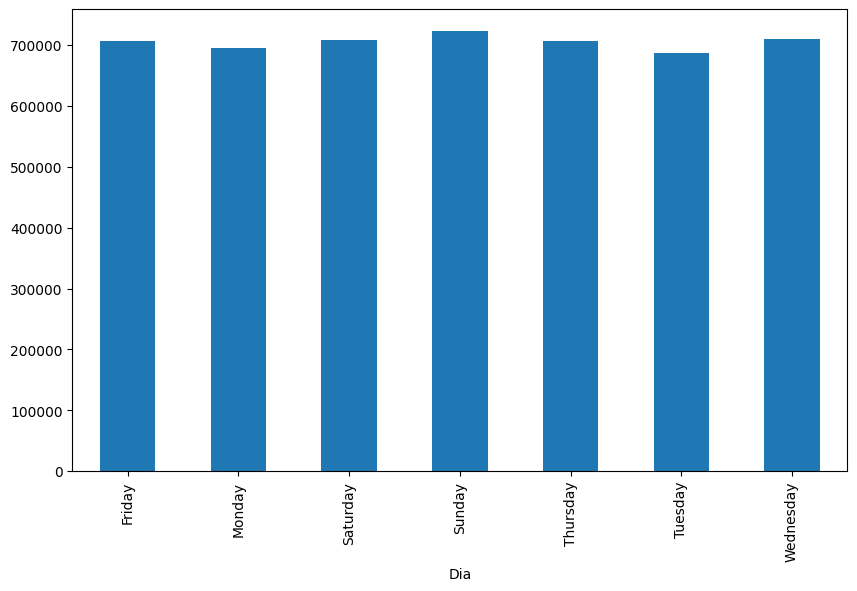

In [78]:
vendas_por_dia['sum'].plot(kind = 'bar', figsize = (10, 6))

### 7. Como as vendas mensais se comparam antes e durante a Black Friday?

In [79]:
black_friday = '2023-11-24'
semana_bf = ['2023-11-20', '2023-11-26']

df['Periodo'] = 'Normal'
df.loc[(df['Data'] >= '2023-11-01') & (df['Data'] < black_friday), 'Periodo'] = 'Antes_BF'
df.loc[(df['Data'] >= '2023-11-20') & (df['Data'] <= '2023-11-26'), 'Periodo'] = 'Durante_BF'

df_novembro = df[(df['Data'].dt.year == 2023) & (df['Data'].dt.month == 11)]
df_novembro




,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,mes,ano,Semana,Dia,faixa_etaria,Periodo
16720,2023-11-01,Maçãs,Alimentos Frescos,4.89,14,0.0,68.46,39,1303.54,11,2023,44,Wednesday,Adulto,Antes_BF
16721,2023-11-01,Bananas,Alimentos Frescos,39.29,11,0.0,432.19,33,2099.26,11,2023,44,Wednesday,Jovem,Antes_BF
16722,2023-11-01,Laranjas,Alimentos Frescos,18.84,6,0.0,113.04,48,3448.47,11,2023,44,Wednesday,Adulto,Antes_BF
16723,2023-11-01,Tomates,Alimentos Frescos,2.55,12,0.0,30.60,20,3128.99,11,2023,44,Wednesday,Jovem,Antes_BF
16724,2023-11-01,Alface,Alimentos Frescos,22.61,14,0.0,316.54,48,4797.62,11,2023,44,Wednesday,Adulto,Antes_BF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18365,2023-11-30,Produtos de higiene para pets,Pet Shop,40.58,12,0.0,486.96,21,4602.77,11,2023,48,Thursday,Jovem,Normal
18366,2023-11-30,Panelas,Utilidades Domésticas,27.32,19,0.0,519.08,57,4304.85,11,2023,48,Thursday,Adulto,Normal
18367,2023-11-30,Talheres,Utilidades Domésticas,13.72,19,0.0,260.68,55,1464.46,11,2023,48,Thursday,Adulto,Normal
18368,2023-11-30,Copos,Utilidades Domésticas,10.14,10,0.0,101.40,69,1977.55,11,2023,48,Thursday,Idoso,Normal


In [80]:
df_novembro.shape

(1650, 15)

In [81]:
comparativo = df_novembro.groupby('Periodo')['Total_Venda'].agg(['sum', 'mean', 'count']).round(2)
print(comparativo)

                  sum    mean  count
Periodo                             
Antes_BF    266205.88  254.74   1045
Durante_BF   76452.08  198.58    385
Normal       43085.42  195.84    220


### Houve mais vendas antes da black friday do que na própria black friday

### 8. Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias do produto?

In [82]:
df.groupby('faixa_etaria')['Total_Venda'].mean().round(2).sort_values(ascending = False)

faixa_etaria
Adulto    247.79
Idoso     247.33
Jovem     242.19
Name: Total_Venda, dtype: float64

In [83]:
df.groupby(['faixa_etaria', 'Categoria'])['Total_Venda'].mean().round(2)

faixa_etaria  Categoria                  
Adulto        Alimentos Frescos              253.66
              Bebidas                        240.42
              Congelados                     245.67
              Laticínios e Ovos              249.26
              Pet Shop                       247.80
              Produtos de Higiene Pessoal    244.52
              Produtos de Limpeza            249.26
              Produtos de Mercearia          242.30
              Utilidades Domésticas          246.39
Idoso         Alimentos Frescos              251.97
              Bebidas                        261.24
              Congelados                     240.42
              Laticínios e Ovos              256.35
              Pet Shop                       234.93
              Produtos de Higiene Pessoal    240.05
              Produtos de Limpeza            238.87
              Produtos de Mercearia          245.31
              Utilidades Domésticas          246.13
Jovem         Alimento

### 9. Comparando a semana da Black Friday com a do Natal, qual semana a empresa teve melhores desempenhos em relação à média de vendas?

In [84]:
semana_natal = ['2023-12-18', '2023-12-24']

df['Periodo'] = 'Normal'
df.loc[(df['Data'] >= '2023-11-01') & (df['Data'] < black_friday), 'Periodo'] = 'Antes_BF'
df.loc[(df['Data'] >= '2023-11-20') & (df['Data'] <= '2023-11-26'), 'Periodo'] = 'Durante_BF'
df.loc[(df['Data'] >= '2023-12-18') & (df['Data'] <= '2023-12-24'), 'Periodo'] = 'Durante_Natal'

df_bf = df.loc[df['Periodo'] == 'Durante_BF']
df_nt = df.loc[df['Periodo'] == 'Durante_Natal']

In [85]:
df_bf.groupby('Periodo')['Total_Venda'].mean().round(2).reset_index()


,Periodo,Total_Venda
0,Durante_BF,198.58


In [86]:
df_nt.groupby('Periodo')['Total_Venda'].mean().round(2).reset_index()

,Periodo,Total_Venda
0,Durante_Natal,225.23


### A semana que a empresa obteve a maior média de vendas foi na semnana do Natal

### 10. Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais produtos tiveram maior aumento nas vendas durante as promoções?

## Essa última questão foi a que eu mais me enrolei

In [87]:
df.head(1)

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,mes,ano,Semana,Dia,faixa_etaria,Periodo
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.6,49,2715.61,1,2023,52,Sunday,Adulto,Normal


In [88]:
df_sem_desconto = df[df['Desconto'] == 0]
df_sem_desconto.shape

(15895, 15)

In [89]:
df_com_desconto = df[df['Desconto'] > 0]
df_com_desconto.shape

(4180, 15)

In [90]:
df_sem_desconto['Quantidade'].mean().round(2)


np.float64(10.01)

In [91]:
df_com_desconto['Quantidade'].mean().round(2)

np.float64(9.99)

In [92]:
df_sem_desconto['Total_Venda'].mean().round(2)

np.float64(256.41)

In [93]:
df_com_desconto['Total_Venda'].mean().round(2)

np.float64(205.93)

In [94]:
media_sem = df_sem_desconto.groupby('Produto')['Quantidade'].mean().round(2).reset_index()


In [95]:
media_com = df_com_desconto.groupby('Produto')['Quantidade'].mean().round(2).reset_index()


In [96]:
media_com = media_com.rename(columns={'Quantidade': 'Qtd_Media_Com_Desconto'})
media_sem = media_sem.rename(columns={'Quantidade': 'Qtd_Media_Sem_Desconto'})



In [97]:
comparativo = pd.merge(media_sem, media_com, on='Produto', how='inner')

comparativo['variacao_percentual'] = ((comparativo['Qtd_Media_Com_Desconto'] - comparativo['Qtd_Media_Sem_Desconto'])/ comparativo['Qtd_Media_Sem_Desconto'] * 100
)

In [98]:
comparativo.sort_values(by='variacao_percentual', ascending=False).head(5)

,Produto,Qtd_Media_Sem_Desconto,Qtd_Media_Com_Desconto,variacao_percentual
19,Frango,9.99,11.38,13.913914
17,Farinha,9.81,11.05,12.640163
5,Bananas,9.33,10.33,10.718114
4,Azeite,9.81,10.80,10.091743
48,Talheres,10.18,11.13,9.332024


### Os produtos que mais se beneficiaram durante as promoções com aumento de venda foram frango, farinha, bananas, azeite e talheres
### O Impacto não foi tão alto quanto o senso comum espera que seja